<a href="https://colab.research.google.com/github/fathanick/Fundamentals-of-Data-Science/blob/main/Support%20Vector%20Machine/Spam_Classification_SVM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Spam Classification using Support Vector Machine (SVM)

This tutorial demonstrates how to classify SMS messages as spam or ham using Support Vector Machine (SVM) with Scikit-learn.

## Step 1: Import Needed Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import string
import nltk
from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

## Step 2: Data Loading

In [2]:
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_csv(url, sep='\t', header=None, names=['label', 'message'])

df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [3]:
df.shape

(5572, 2)

In [4]:
df['label'].value_counts()

,count
label,
ham,4825
spam,747


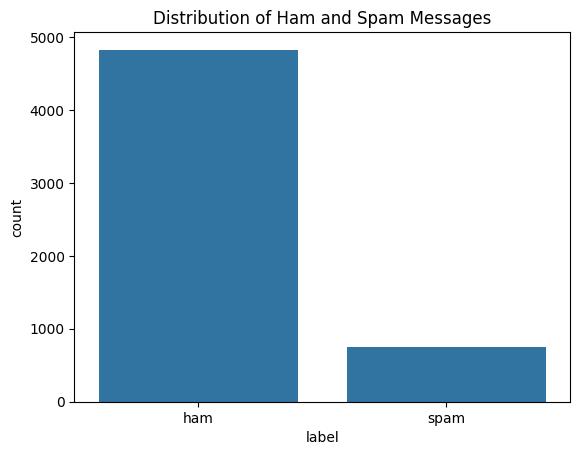

In [5]:
sns.countplot(data=df, x='label')
plt.title('Distribution of Ham and Spam Messages')
plt.show()

## Step 3: Data Preprocessing

In [6]:
def preprocess_text(text):
    text = text.lower()
    text = ''.join([char for char in text if char not in string.punctuation])

    stop_words = set(stopwords.words('english'))
    words = text.split()
    words = [word for word in words if word not in stop_words]

    return ' '.join(words)

In [7]:
df['clean_message'] = df['message'].apply(preprocess_text)

df[['message', 'clean_message']].head()

,message,clean_message
0,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...
1,Ok lar... Joking wif u oni...,ok lar joking wif u oni
2,Free entry in 2 a wkly comp to win FA Cup fina...,free entry 2 wkly comp win fa cup final tkts 2...
3,U dun say so early hor... U c already then say...,u dun say early hor u c already say
4,"Nah I don't think he goes to usf, he lives aro...",nah dont think goes usf lives around though


## Step 4: Feature Extraction

In [8]:
X = df['clean_message']
y = df['label']

vectorizer = CountVectorizer()
X_vectorized = vectorizer.fit_transform(X)

print(X_vectorized.shape)

(5572, 9437)


## Step 5: Data Splitting

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_vectorized,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('Training shape:', X_train.shape)
print('Testing shape:', X_test.shape)

Training shape: (4457, 9437)
Testing shape: (1115, 9437)


## Step 6: Classification using SVM

In [10]:
svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train, y_train)

LinearSVC(random_state=42)

In [11]:
y_pred = svm_model.predict(X_test)

pd.DataFrame({
    'Actual': y_test.values[:10],
    'Predicted': y_pred[:10]
})

,Actual,Predicted
0,ham,ham
1,ham,ham
2,ham,ham
3,spam,spam
4,ham,ham
5,ham,ham
6,ham,ham
7,ham,ham
8,ham,ham
9,ham,ham


## Step 7: Evaluation

In [12]:
accuracy = accuracy_score(y_test, y_pred)
print('Accuracy:', accuracy)

Accuracy: 0.9847533632286996


In [13]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       966
        spam       1.00      0.89      0.94       149

    accuracy                           0.98      1115
   macro avg       0.99      0.94      0.97      1115
weighted avg       0.99      0.98      0.98      1115



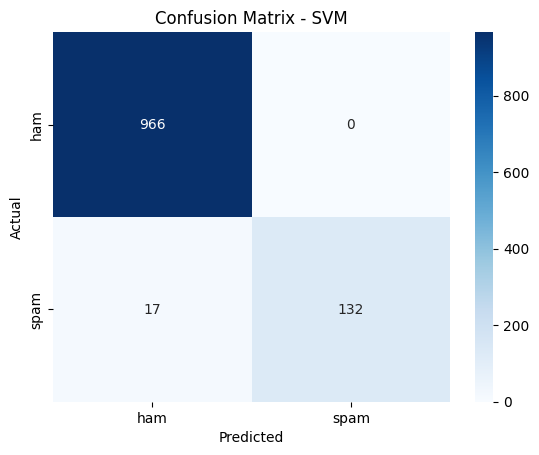

In [14]:
cm = confusion_matrix(y_test, y_pred, labels=['ham', 'spam'])

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['ham', 'spam'],
    yticklabels=['ham', 'spam']
)

plt.title('Confusion Matrix - SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Step 8: Inference

In [15]:
new_messages = [
    'Congratulations! You have won a free ticket. Claim now!',
    'Hi, are we still meeting for lunch today?',
    'URGENT! Your account has been selected for a cash prize.',
    'Please call me when you arrive.'
]

clean_new_messages = [preprocess_text(msg) for msg in new_messages]
new_messages_vectorized = vectorizer.transform(clean_new_messages)

predictions = svm_model.predict(new_messages_vectorized)

for message, prediction in zip(new_messages, predictions):
    print('Message:', message)
    print('Prediction:', prediction)
    print()

Message: Congratulations! You have won a free ticket. Claim now!
Prediction: ham

Message: Hi, are we still meeting for lunch today?
Prediction: ham

Message: URGENT! Your account has been selected for a cash prize.
Prediction: spam

Message: Please call me when you arrive.
Prediction: ham



## Step 9: Save the Model and Vectorizer

In [16]:
import joblib

# Save the SVM model
joblib.dump(svm_model, 'svm_model.pkl')
print('SVM model saved to svm_model.pkl')

# Save the CountVectorizer
joblib.dump(vectorizer, 'vectorizer.pkl')
print('CountVectorizer saved to vectorizer.pkl')

SVM model saved to svm_model.pkl
CountVectorizer saved to vectorizer.pkl
